In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings as wr

wr.filterwarnings('ignore')

In [2]:
ratings_df = pd.read_csv("moviedata/ratings.csv", usecols=["Name", "Rating"])

In [97]:
movies_df = pd.read_csv("moviedata/movies.csv")

In [22]:
data_df = movies_df.merge(ratings_df, left_on="Title", right_on="Name", how="inner")

In [5]:
rating_counts = data_df["Rating"].value_counts()

In [6]:
rating_counts

Rating
4.0    26
5.0    18
4.5    17
3.5    11
3.0     9
2.0     2
1.0     1
1.5     1
Name: count, dtype: int64

In [27]:
data_df["BoxOffice"] = data_df["BoxOffice"].str.replace(",", "")
data_df["BoxOffice"] = data_df["BoxOffice"].str.replace("$", "")

In [28]:
data_df["BoxOffice"] = pd.to_numeric(data_df["BoxOffice"], errors="coerce")

<BarContainer object of 8 artists>

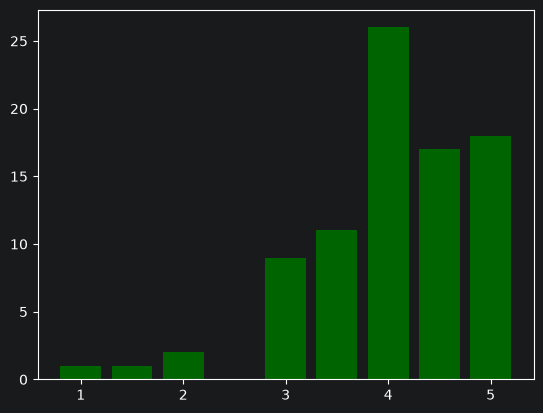

In [29]:
plt.bar(rating_counts.index, rating_counts, color="darkgreen", width=0.4)

<Axes: xlabel='Rating', ylabel='BoxOffice'>

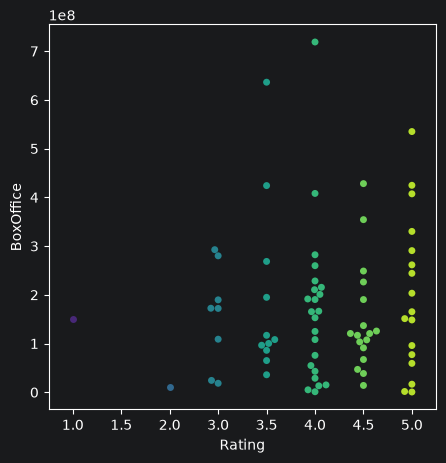

In [30]:
plt.figure(figsize=(5,5))
sns.swarmplot(x="Rating", y="BoxOffice", data=data_df, palette="viridis")

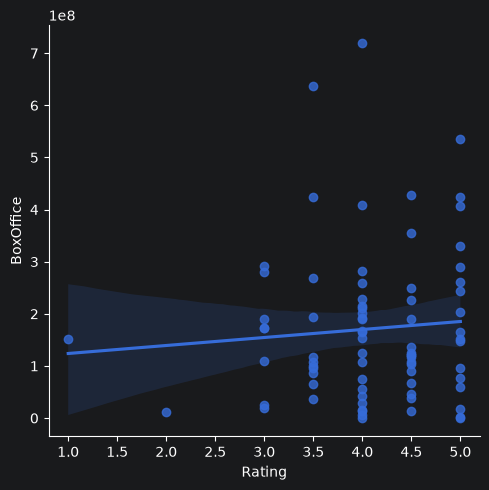

In [31]:
sns.lmplot(data=data_df, x="Rating", y="BoxOffice", palette="viridis")

In [60]:
corr_df = data_df.corr(numeric_only=True)
corr_df.dropna(axis=0, how="all", inplace=True)
corr_df.dropna(axis=1, how="all", inplace=True)
corr_df

,Year,Metascore,imdbRating,BoxOffice,Rating
Year,1.000000,-0.102293,-0.270497,0.170062,-0.341214
Metascore,-0.102293,1.000000,0.753369,0.126362,0.316288
imdbRating,-0.270497,0.753369,1.000000,0.071759,0.330822
BoxOffice,0.170062,0.126362,0.071759,1.000000,0.080273
Rating,-0.341214,0.316288,0.330822,0.080273,1.000000


<Axes: >

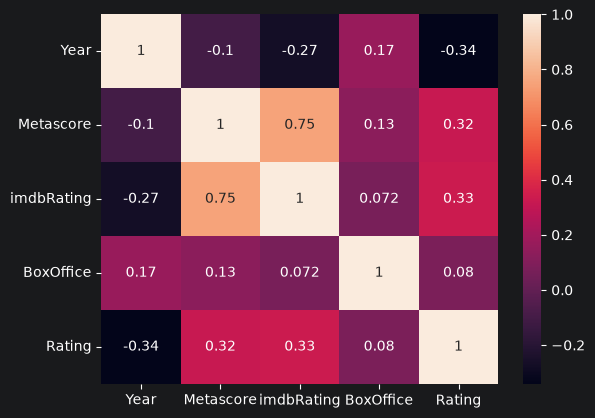

In [102]:
sns.heatmap(data=corr_df, annot=True)

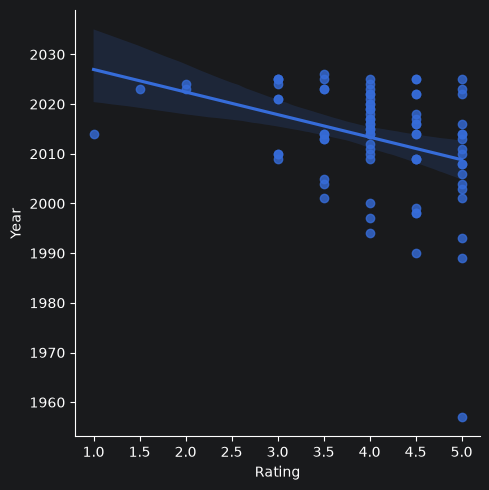

In [63]:
sns.lmplot(data=data_df, x="Rating", y="Year", palette="viridis")

In [100]:
anti_df = ratings_df.merge(movies_df, how="left_anti", left_on="Name", right_on="Title")["Name"]

In [101]:
anti_df

47    Kingsman: The Secret Service
75    The Fantastic 4: First Steps
Name: Name, dtype: str